<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2001h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

00000  var_x=3.024131e-05  vac_E=3.105928e-05  max_amp=9.520303e-02  patch_amp=8.645497e-02  kin_E=8.634532e-09  pot_E=3.765310e-08  tot_E=4.628763e-08
00010  var_x=6.923486e-06  vac_E=7.311332e-06  max_amp=3.566411e-02  patch_amp=2.341436e-02  kin_E=1.562178e-07  pot_E=-2.364857e-08  tot_E=1.325693e-07
00020  var_x=1.613549e-05  vac_E=1.622039e-05  max_amp=5.866557e-02  patch_amp=5.825775e-02  kin_E=8.229262e-08  pot_E=-4.404668e-08  tot_E=3.824594e-08
00030  var_x=1.824047e-05  vac_E=1.825837e-05  max_amp=3.436217e-02  patch_amp=1.271663e-02  kin_E=9.062985e-08  pot_E=-6.141305e-08  tot_E=2.921680e-08
00040  var_x=1.556427e-05  vac_E=1.558287e-05  max_amp=2.327451e-02  patch_amp=1.036508e-02  kin_E=9.405966e-08  pot_E=-7.245317e-08  tot_E=2.160648e-08
00050  var_x=1.521180e-05  vac_E=1.526261e-05  max_amp=1.778154e-02  patch_amp=1.650645e-02  kin_E=8.971120e-08  pot_E=-7.910443e-08  tot_E=1.060677e-08
00060  var_x=1.590124e-05  vac_E=1.603382e-05  max_amp=1.457473e-02  patch_amp=1.43

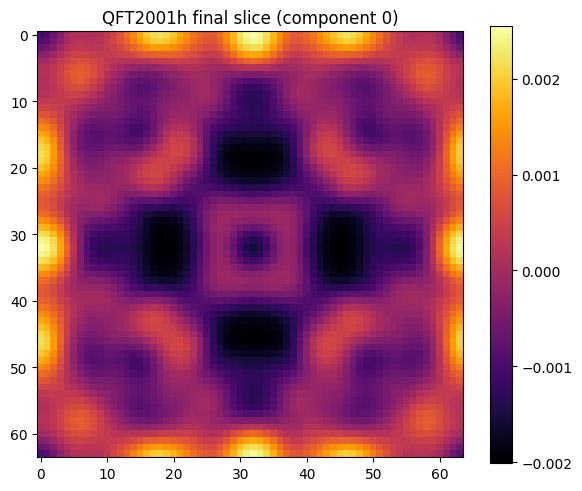

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2001h — Collapse Threshold Test
# ============================================================

L = 64
N_int = 100
steps = 3000  # long run to observe collapse or stabilization

lambda_c = 0.08   # strong coupling
gamma    = 0.001  # extremely weak damping
alpha    = 4.0    # strong nonlinearity
noise_amp = 5e-5  # tiny symmetry-breaking noise

# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------
rng = np.random.default_rng(4001)

x = noise_amp * rng.normal(size=(L, L, L, N_int))

cx = cy = cz = L // 2
X, Y, Z = np.meshgrid(np.arange(L), np.arange(L), np.arange(L), indexing='ij')
R2 = (X - cx)**2 + (Y - cy)**2 + (Z - cz)**2
bump = np.exp(-R2 / (2 * (L/12)**2))

# Strong initial bump to enter collapse regime
x += 0.10 * bump[..., None]

v = np.zeros_like(x)

# ------------------------------------------------------------
# Laplacian
# ------------------------------------------------------------
def laplacian(f):
    return (
        np.roll(f, 1, 0) + np.roll(f, -1, 0) +
        np.roll(f, 1, 1) + np.roll(f, -1, 1) +
        np.roll(f, 1, 2) + np.roll(f, -1, 2) -
        6.0 * f
    )

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
def diagnostics(step, x, v):
    var_x = np.var(x)
    vac_E = np.mean(x**2)
    max_amp = np.max(np.abs(x))
    patch = x[cx-2:cx+3, cy-2:cy+3, cz-2:cz+3]
    patch_amp = np.mean(np.abs(patch))
    kin_E = 0.5 * np.mean(v**2)
    pot_E = 0.5 * lambda_c * np.mean(x * laplacian(x)) + 0.25 * alpha * np.mean(x**4)
    tot_E = kin_E + pot_E
    print(
        f"{step:05d}  var_x={var_x:.6e}  vac_E={vac_E:.6e}  "
        f"max_amp={max_amp:.6e}  patch_amp={patch_amp:.6e}  "
        f"kin_E={kin_E:.6e}  pot_E={pot_E:.6e}  tot_E={tot_E:.6e}"
    )

# ------------------------------------------------------------
# Main evolution loop
# ------------------------------------------------------------
for step in range(steps):
    lap = laplacian(x)
    force = lambda_c * lap - alpha * x**3
    v = (1 - gamma) * v + force
    x = x + v

    if step % 10 == 0:
        diagnostics(step, x, v)

# ------------------------------------------------------------
# Final slice plot
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
plt.imshow(x[:, :, L//2, 0], cmap='inferno')
plt.colorbar()
plt.title("QFT2001h final slice (component 0)")
plt.tight_layout()
plt.show()
